In [1]:
import subprocess, sys

packages = [
    "imutils",
    "tqdm",
    "opencv-python",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "plotly",
    "tensorflow",
    "numpy",
    "pandas",
    "Pillow",
    "natsort"
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

print("All packages installed ✓")

All packages installed ✓


In [2]:
import numpy as np
import os
from imutils import paths
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import tensorflow as tf
from tqdm import tqdm
import cv2
import warnings
warnings.filterwarnings('ignore')

In [7]:
# ── CONFIG ───────────────────────────────────────────────────────────────────
DATASET      = r'C:\Users\Anish Kumar\Downloads\Brain tumor'   # <-- your path
IMG_SIZE     = 260        # EfficientNetB4 native input; matches your images exactly
BATCH_SIZE   = 32
EPOCHS_HEAD  = 10         # train only top layers first (fast warm-up)
EPOCHS_FINE  = 20         # fine-tune deeper layers
LR_HEAD      = 1e-3
LR_FINE      = 1e-5
MODEL_SAVE   = r'C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5'

CLASS_LABELS = ['Glioma', 'Meningioma', 'Healthy', 'Pituitary']  # adjust if different
print("Config ready ✓")

Config ready ✓


In [8]:
imagePaths = list(paths.list_images(DATASET))
data   = []
labels = []

for imgPath in tqdm(imagePaths, desc="Loading images"):
    label = imgPath.split(os.path.sep)[-2]
    img   = load_img(imgPath, target_size=(IMG_SIZE, IMG_SIZE))   # rescale to 260x260
    img   = img_to_array(img)
    img   = preprocess_input(img)    # EfficientNet-specific preprocessing
    data.append(img)
    labels.append(label)

data   = np.array(data,   dtype="float32")
labels = np.array(labels)
print(f"Data shape   : {data.shape}")
print(f"Unique labels: {np.unique(labels)}")

Loading images: 100%|█████████████████████████████████████████████████████████████| 6365/6365 [00:17<00:00, 363.31it/s]


Data shape   : (6365, 260, 260, 3)
Unique labels: ['Glioma' 'Healthy' 'Meningioma' 'Pituitary']


In [9]:
lb = LabelBinarizer()
labels_enc = lb.fit_transform(labels)
CLASS_LABELS = list(lb.classes_)
print("Classes:", CLASS_LABELS)

X_train, X_test, y_train, y_test = train_test_split(
    data, labels_enc,
    test_size=0.20,
    stratify=labels_enc,
    random_state=42
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Classes: [np.str_('Glioma'), np.str_('Healthy'), np.str_('Meningioma'), np.str_('Pituitary')]
Train: (5092, 260, 260, 3)  |  Test: (1273, 260, 260, 3)


In [10]:
aug = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    vertical_flip=False,
    fill_mode='nearest'
)
print("Augmentation generator ready ✓")

Augmentation generator ready ✓


In [11]:
# Base model — EfficientNetB4 native size is 380px but works well at 260px too
baseModel = EfficientNetB4(
    weights="imagenet",
    include_top=False,
    input_tensor=Input(shape=(IMG_SIZE, IMG_SIZE, 3))
)

# Freeze base for warm-up
baseModel.trainable = False

# Custom classification head
x = baseModel.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(len(CLASS_LABELS), activation="softmax")(x)

model = Model(inputs=baseModel.input, outputs=output)
print(f"Total layers : {len(model.layers)}")
print(f"Output classes: {len(CLASS_LABELS)}")
model.summary()

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Total layers : 481
Output classes: 4


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 260, 260, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 260, 260, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 260, 260, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 260, 260, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 261, 261, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 130, 130, 48)      │           1,296 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 130, 130, 48)      │             192 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 130, 130, 48)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 130, 130, 48)      │             432 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 130, 130, 48)      │             192 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 130, 130, 48)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 48)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 48)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 12)          │             588 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 48)          │             624 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 18,166,243 (69.30 MB)

 Trainable params: 492,420 (1.88 MB)

 Non-trainable params: 17,673,823 (67.42 MB)

In [12]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(MODEL_SAVE, monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]
print("Callbacks ready ✓")

Callbacks ready ✓


In [13]:
model.compile(
    optimizer=Adam(learning_rate=LR_HEAD),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("[PHASE 1] Training classification head only...")
H1 = model.fit(
    aug.flow(X_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=(X_test, y_test),
    epochs=EPOCHS_HEAD,
    callbacks=callbacks,
    verbose=1
)

[PHASE 1] Training classification head only...
Epoch 1/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6838 - loss: 0.7696
Epoch 1: val_accuracy improved from None to 0.83111, saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5



Epoch 1: finished saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 854s 5s/step - accuracy: 0.7425 - loss: 0.6285 - val_accuracy: 0.8311 - val_loss: 0.4257 - learning_rate: 0.0010
Epoch 2/10
  1/159 ━━━━━━━━━━━━━━━━━━━━ 10:29 4s/step - accuracy: 0.8125 - loss: 0.4378
Epoch 2: val_accuracy improved from 0.83111 to 0.83818, saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5



Epoch 2: finished saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.8125 - loss: 0.4378 - val_accuracy: 0.8382 - val_loss: 0.4223 - learning_rate: 0.0010
Epoch 3/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8163 - loss: 0.4692
Epoch 3: val_accuracy improved from 0.83818 to 0.86253, saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5



Epoch 3: finished saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 874s 6s/step - accuracy: 0.8310 - loss: 0.4424 - val_accuracy: 0.8625 - val_loss: 0.3568 - learning_rate: 0.0010
Epoch 4/10
  1/159 ━━━━━━━━━━━━━━━━━━━━ 11:37 4s/step - accuracy: 0.8750 - loss: 0.4259
Epoch 4: val_accuracy improved from 0.86253 to 0.86489, saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5



Epoch 4: finished saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.8750 - loss: 0.4259 - val_accuracy: 0.8649 - val_loss: 0.3516 - learning_rate: 0.0010
Epoch 5/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8536 - loss: 0.3829
Epoch 5: val_accuracy did not improve from 0.86489
159/159 ━━━━━━━━━━━━━━━━━━━━ 1006s 6s/step - accuracy: 0.8609 - loss: 0.3668 - val_accuracy: 0.8602 - val_loss: 0.3689 - learning_rate: 0.0010
Epoch 6/10
  1/159 ━━━━━━━━━━━━━━━━━━━━ 11:53 5s/step - accuracy: 0.7188 - loss: 0.6234
Epoch 6: val_accuracy did not improve from 0.86489
159/159 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.7188 - loss: 0.6234 - val_accuracy: 0.8586 - val_loss: 0.3709 - learning_rate: 0.0010
Epoch 7/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8621 - loss: 0.3543
Epoch 7: val_accuracy improved from 0.86489 to 0.87431, saving model to C:\Users\Anish Kumar\Downloads\Brain tu


Epoch 7: finished saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 1282s 8s/step - accuracy: 0.8644 - loss: 0.3491 - val_accuracy: 0.8743 - val_loss: 0.3145 - learning_rate: 0.0010
Epoch 8/10
  1/159 ━━━━━━━━━━━━━━━━━━━━ 12:24 5s/step - accuracy: 0.7500 - loss: 0.5433
Epoch 8: val_accuracy improved from 0.87431 to 0.87745, saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5



Epoch 8: finished saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 441s 3s/step - accuracy: 0.7500 - loss: 0.5433 - val_accuracy: 0.8775 - val_loss: 0.3120 - learning_rate: 0.0010
Epoch 9/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8753 - loss: 0.3189
Epoch 9: val_accuracy improved from 0.87745 to 0.89395, saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5



Epoch 9: finished saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 946s 6s/step - accuracy: 0.8686 - loss: 0.3324 - val_accuracy: 0.8940 - val_loss: 0.2770 - learning_rate: 0.0010
Epoch 10/10
  1/159 ━━━━━━━━━━━━━━━━━━━━ 11:14 4s/step - accuracy: 0.8125 - loss: 0.4005
Epoch 10: val_accuracy improved from 0.89395 to 0.89631, saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5



Epoch 10: finished saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.8125 - loss: 0.4005 - val_accuracy: 0.8963 - val_loss: 0.2801 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.


In [14]:
# Unfreeze last 60 layers of EfficientNetB4 for fine-tuning
for layer in baseModel.layers[-60:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=LR_FINE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("[PHASE 2] Fine-tuning top layers...")
H2 = model.fit(
    aug.flow(X_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=(X_test, y_test),
    epochs=EPOCHS_FINE,
    callbacks=callbacks,
    verbose=1
)

[PHASE 2] Fine-tuning top layers...
Epoch 1/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8900 - loss: 0.2921
Epoch 1: val_accuracy improved from 0.89631 to 0.90888, saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5



Epoch 1: finished saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 1019s 6s/step - accuracy: 0.8943 - loss: 0.2836 - val_accuracy: 0.9089 - val_loss: 0.2493 - learning_rate: 1.0000e-05
Epoch 2/20
  1/159 ━━━━━━━━━━━━━━━━━━━━ 14:34 6s/step - accuracy: 0.9688 - loss: 0.1618
Epoch 2: val_accuracy improved from 0.90888 to 0.90966, saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5



Epoch 2: finished saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.9688 - loss: 0.1618 - val_accuracy: 0.9097 - val_loss: 0.2493 - learning_rate: 1.0000e-05
Epoch 3/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8985 - loss: 0.2616
Epoch 3: val_accuracy improved from 0.90966 to 0.91280, saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5



Epoch 3: finished saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 1156s 7s/step - accuracy: 0.8996 - loss: 0.2554 - val_accuracy: 0.9128 - val_loss: 0.2369 - learning_rate: 1.0000e-05
Epoch 4/20
  1/159 ━━━━━━━━━━━━━━━━━━━━ 19:34 7s/step - accuracy: 0.8438 - loss: 0.3205
Epoch 4: val_accuracy did not improve from 0.91280
159/159 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.8438 - loss: 0.3205 - val_accuracy: 0.9128 - val_loss: 0.2366 - learning_rate: 1.0000e-05
Epoch 5/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.9049 - loss: 0.2347 
Epoch 5: val_accuracy improved from 0.91280 to 0.92066, saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5



Epoch 5: finished saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 2220s 14s/step - accuracy: 0.9079 - loss: 0.2329 - val_accuracy: 0.9207 - val_loss: 0.2224 - learning_rate: 1.0000e-05
Epoch 6/20
  1/159 ━━━━━━━━━━━━━━━━━━━━ 13:53 5s/step - accuracy: 0.8438 - loss: 0.2722
Epoch 6: val_accuracy did not improve from 0.92066
159/159 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.8438 - loss: 0.2722 - val_accuracy: 0.9191 - val_loss: 0.2228 - learning_rate: 1.0000e-05
Epoch 7/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9165 - loss: 0.2271
Epoch 7: val_accuracy improved from 0.92066 to 0.92537, saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5


...


Epoch 8: finished saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.9688 - loss: 0.1474 - val_accuracy: 0.9262 - val_loss: 0.2132 - learning_rate: 1.0000e-05
Epoch 9/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9316 - loss: 0.1957
Epoch 9: val_accuracy did not improve from 0.92616
159/159 ━━━━━━━━━━━━━━━━━━━━ 1000s 6s/step - accuracy: 0.9271 - loss: 0.1992 - val_accuracy: 0.9238 - val_loss: 0.2076 - learning_rate: 1.0000e-05
Epoch 10/20
  1/159 ━━━━━━━━━━━━━━━━━━━━ 14:22 5s/step - accuracy: 0.9688 - loss: 0.1167
Epoch 10: val_accuracy did not improve from 0.92616
159/159 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.9688 - loss: 0.1167 - val_accuracy: 0.9246 - val_loss: 0.2073 - learning_rate: 1.0000e-05
Epoch 11/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9341 - loss: 0.1929
Epoch 11: val_accuracy did not improve from 0.92616
159/159 ━━━━━━━━━━━━━━━━━━━━ 1036s 7s/step -


Epoch 13: finished saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 1066s 7s/step - accuracy: 0.9302 - loss: 0.1825 - val_accuracy: 0.9348 - val_loss: 0.1881 - learning_rate: 1.0000e-05
Epoch 14/20
  1/159 ━━━━━━━━━━━━━━━━━━━━ 14:47 6s/step - accuracy: 0.8750 - loss: 0.2821
Epoch 14: val_accuracy did not improve from 0.93480
159/159 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.8750 - loss: 0.2821 - val_accuracy: 0.9348 - val_loss: 0.1863 - learning_rate: 1.0000e-05
Epoch 15/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9352 - loss: 0.1610
Epoch 15: val_accuracy did not improve from 0.93480
159/159 ━━━━━━━━━━━━━━━━━━━━ 1007s 6s/step - accuracy: 0.9344 - loss: 0.1662 - val_accuracy: 0.9293 - val_loss: 0.1916 - learning_rate: 1.0000e-05
Epoch 16/20
  1/159 ━━━━━━━━━━━━━━━━━━━━ 14:46 6s/step - accuracy: 0.8750 - loss: 0.3287
Epoch 16: val_accuracy did not improve from 0.93480
159/159 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/


Epoch 17: finished saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 1077s 7s/step - accuracy: 0.9389 - loss: 0.1581 - val_accuracy: 0.9372 - val_loss: 0.1737 - learning_rate: 1.0000e-05
Epoch 18/20
  1/159 ━━━━━━━━━━━━━━━━━━━━ 14:48 6s/step - accuracy: 0.9375 - loss: 0.4348
Epoch 18: val_accuracy improved from 0.93716 to 0.93951, saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5



Epoch 18: finished saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.9375 - loss: 0.4348 - val_accuracy: 0.9395 - val_loss: 0.1737 - learning_rate: 1.0000e-05
Epoch 19/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9463 - loss: 0.1498
Epoch 19: val_accuracy improved from 0.93951 to 0.94423, saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5



Epoch 19: finished saving model to C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 1046s 6s/step - accuracy: 0.9462 - loss: 0.1492 - val_accuracy: 0.9442 - val_loss: 0.1741 - learning_rate: 1.0000e-05
Epoch 20/20
  1/159 ━━━━━━━━━━━━━━━━━━━━ 13:24 5s/step - accuracy: 0.9688 - loss: 0.1003
Epoch 20: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 20: val_accuracy did not improve from 0.94423
159/159 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.9688 - loss: 0.1003 - val_accuracy: 0.9427 - val_loss: 0.1737 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 19.


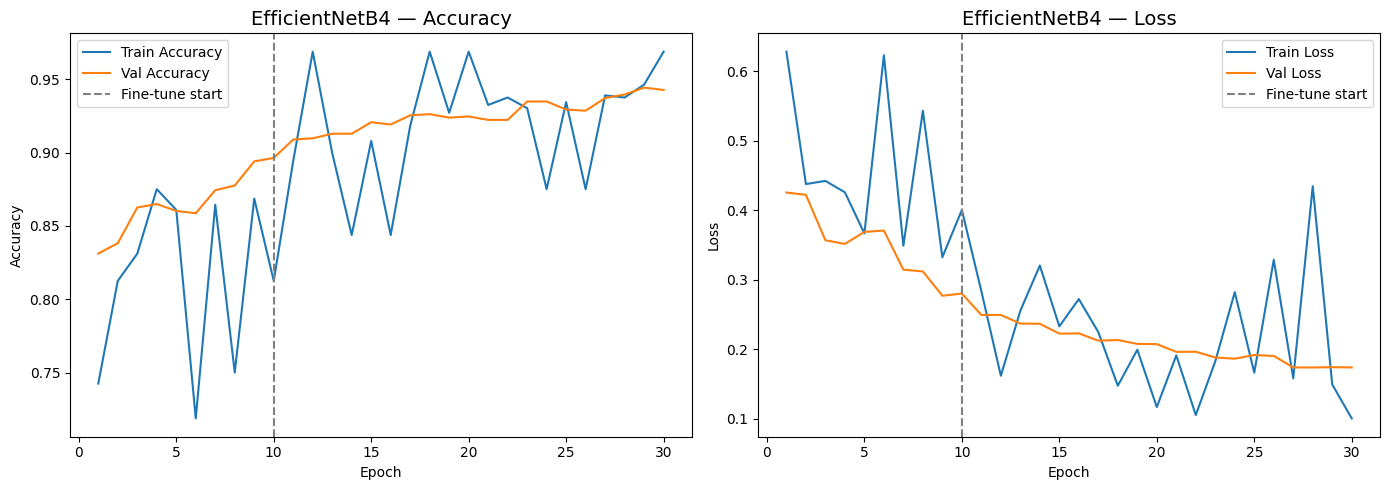

In [15]:
# Merge both phases
acc      = H1.history['accuracy']      + H2.history['accuracy']
val_acc  = H1.history['val_accuracy']  + H2.history['val_accuracy']
loss     = H1.history['loss']          + H2.history['loss']
val_loss = H1.history['val_loss']      + H2.history['val_loss']

epochs_range = range(1, len(acc) + 1)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc,     label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Val Accuracy')
plt.axvline(x=EPOCHS_HEAD, color='gray', linestyle='--', label='Fine-tune start')
plt.title('EfficientNetB4 — Accuracy', fontsize=14)
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss,     label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.axvline(x=EPOCHS_HEAD, color='gray', linestyle='--', label='Fine-tune start')
plt.title('EfficientNetB4 — Loss', fontsize=14)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
print("[INFO] Evaluating model...")
preds    = model.predict(X_test, batch_size=BATCH_SIZE)
y_pred   = np.argmax(preds,   axis=1)
y_test_1d = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_test_1d, y_pred, target_names=CLASS_LABELS))

[INFO] Evaluating model...
40/40 ━━━━━━━━━━━━━━━━━━━━ 171s 4s/step

Classification Report:
              precision    recall  f1-score   support

      Glioma       1.00      0.87      0.93       318
     Healthy       0.98      0.98      0.98       319
  Meningioma       0.87      0.94      0.91       318
   Pituitary       0.93      0.98      0.96       318

    accuracy                           0.94      1273
   macro avg       0.95      0.94      0.94      1273
weighted avg       0.95      0.94      0.94      1273



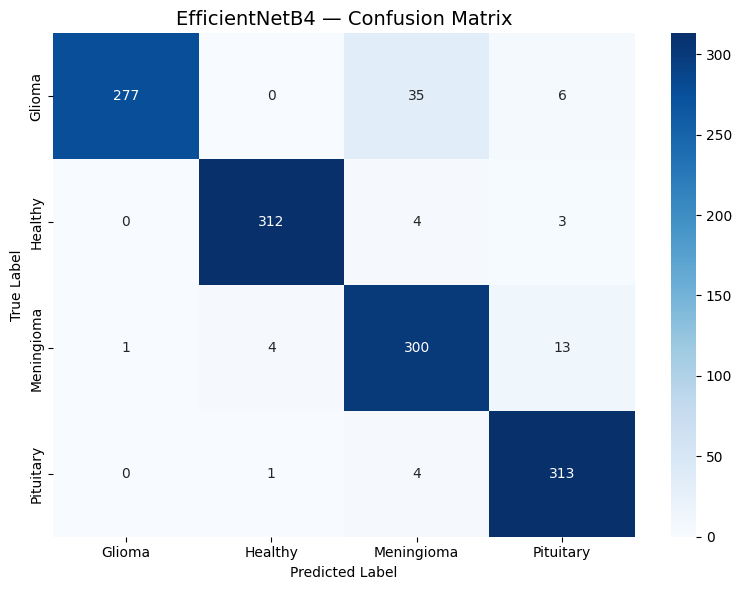

In [17]:
cm = confusion_matrix(y_test_1d, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS)
plt.title('EfficientNetB4 — Confusion Matrix', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

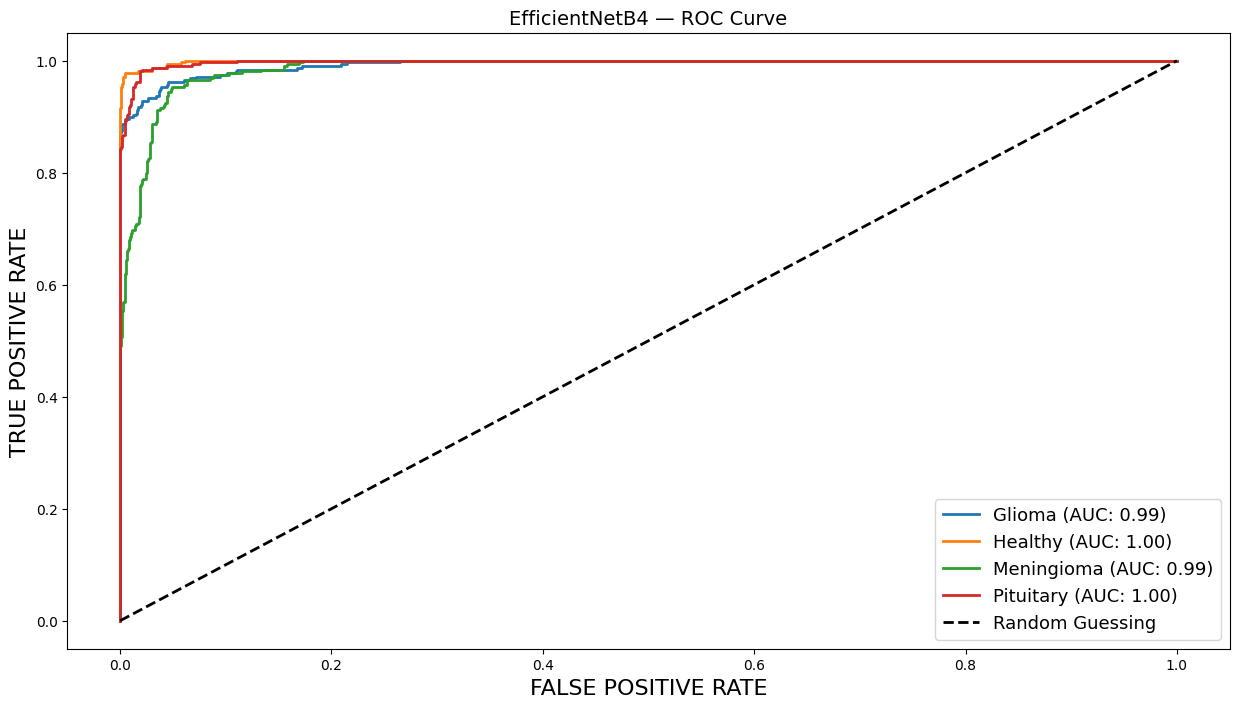

In [18]:
from sklearn.preprocessing import label_binarize

y_test_bin = y_test   # already binarized from LabelBinarizer

fig, c_ax = plt.subplots(1, 1, figsize=(15, 8))

for idx, c_label in enumerate(CLASS_LABELS):
    fpr, tpr, _ = roc_curve(y_test_bin[:, idx].astype(int), preds[:, idx])
    c_ax.plot(fpr, tpr, lw=2, label=f'{c_label} (AUC: {auc(fpr, tpr):0.2f})')

c_ax.plot([0, 1], [0, 1], 'black', linestyle='dashed', lw=2, label='Random Guessing')
plt.xlabel('FALSE POSITIVE RATE', fontsize=16)
plt.ylabel('TRUE POSITIVE RATE',  fontsize=16)
plt.title('EfficientNetB4 — ROC Curve', fontsize=14)
plt.legend(fontsize=13)
plt.show()

In [19]:
roc_macro = roc_auc_score(y_test, preds, average="macro",  multi_class="ovr")
roc_micro = roc_auc_score(y_test, preds, average="micro",  multi_class="ovr")

print(f"ROC-AUC (Macro, OvR) = {roc_macro:.4f}")
print(f"ROC-AUC (Micro, OvR) = {roc_micro:.4f}")

ROC-AUC (Macro, OvR) = 0.9941
ROC-AUC (Micro, OvR) = 0.9948


In [20]:
model.save(MODEL_SAVE)
print(f"Model saved → {MODEL_SAVE}")

Model saved → C:\Users\Anish Kumar\Downloads\Brain tumor\model\EfficientNetB4.h5
